In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, auc,
    average_precision_score, f1_score,
    precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

In [3]:
# ── Load Model & Data ─────────────────────────────────────
xgb_model = joblib.load('models/xgboost_fraud_model.pkl')

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

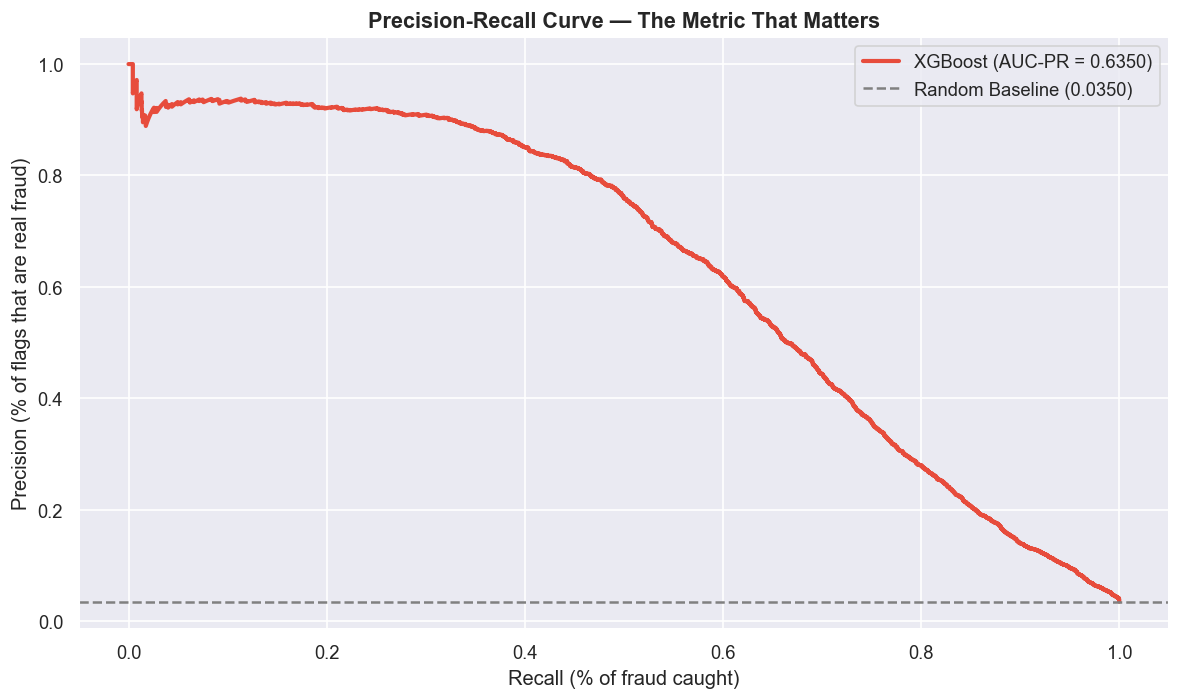


[SECTION 1] Average Precision (AUC-PR): 0.6350


In [5]:
# ============================================================
# SECTION 1: PRECISION-RECALL CURVE
# Business Question: At what threshold should we flag fraud?
# Reason: ROC curve looks great even for bad models on imbalanced data — PR curve tells the real story
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='#e74c3c', linewidth=2.5, label=f'XGBoost (AUC-PR = {avg_precision:.4f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Random Baseline ({y_test.mean():.4f})')
plt.xlabel('Recall (% of fraud caught)')
plt.ylabel('Precision (% of flags that are real fraud)')
plt.title('Precision-Recall Curve — The Metric That Matters', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/eval_01_precision_recall.png', bbox_inches='tight')
plt.show()

print(f"\n[SECTION 1] Average Precision (AUC-PR): {avg_precision:.4f}")


[SECTION 2] Threshold Analysis Table
 threshold  precision  recall  f1_score  transactions_flagged
       0.1     0.0521  0.9903    0.0991                 78510
       0.2     0.0884  0.9572    0.1619                 44734
       0.3     0.1324  0.9085    0.2311                 28370
       0.4     0.1822  0.8698    0.3013                 19733
       0.5     0.2441  0.8260    0.3768                 13988
       0.6     0.3282  0.7660    0.4595                  9648
       0.7     0.4482  0.6971    0.5456                  6428
       0.8     0.6068  0.6061    0.6065                  4128
       0.9     0.8047  0.4604    0.5857                  2365


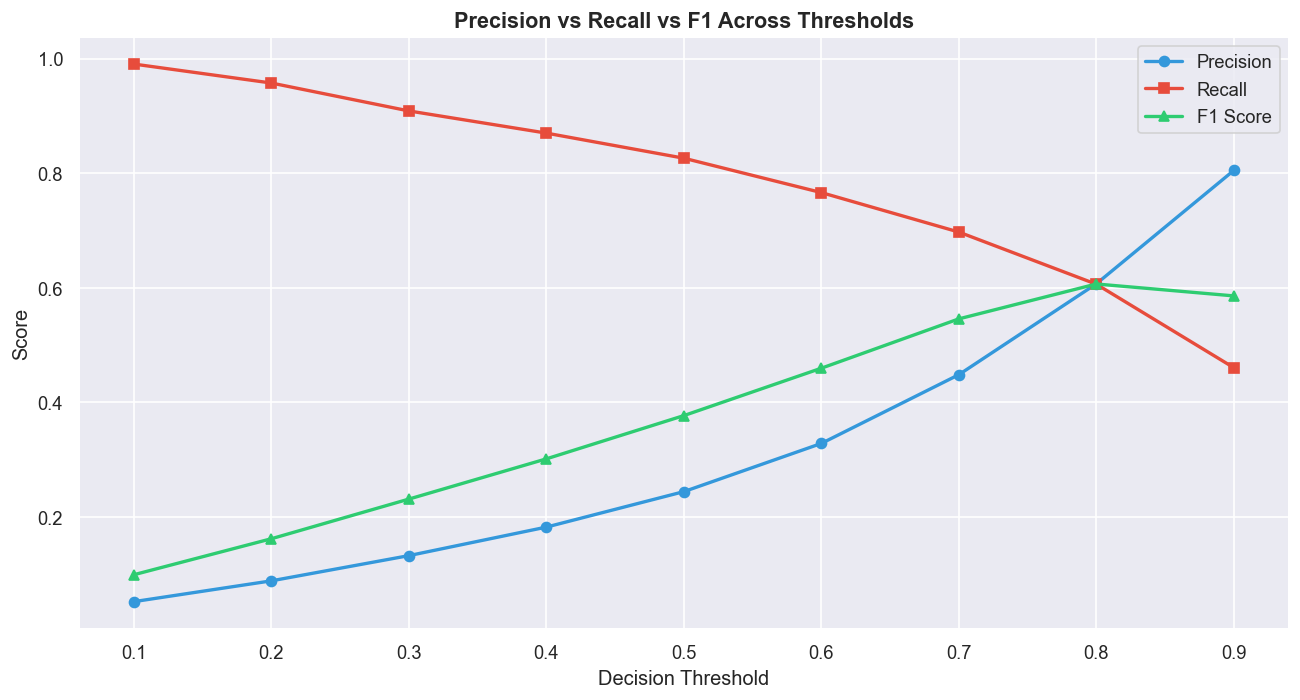


[OPTIMAL THRESHOLD by F1] 0.8 (Precision: 0.6068, Recall: 0.6061, F1: 0.6065)


In [6]:
# ============================================================
# SECTION 2: THRESHOLD ANALYSIS
# Business Question: What happens at different decision thresholds? Default 0.5 is rarely optimal for imbalanced fraud problems.
# ============================================================

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for t in thresholds_to_test:
    y_pred = (y_pred_proba >= t).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    flagged = y_pred.sum()
    results.append({
        'threshold': t,
        'precision': round(p, 4),
        'recall': round(r, 4),
        'f1_score': round(f1, 4),
        'transactions_flagged': flagged
    })

threshold_df = pd.DataFrame(results)
print(f"\n[SECTION 2] Threshold Analysis Table")
print(threshold_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(threshold_df['threshold'], threshold_df['precision'],
        marker='o', label='Precision', color='#3498db', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['recall'],
        marker='s', label='Recall', color='#e74c3c', linewidth=2)
ax.plot(threshold_df['threshold'], threshold_df['f1_score'],
        marker='^', label='F1 Score', color='#2ecc71', linewidth=2)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall vs F1 Across Thresholds', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/eval_02_threshold_analysis.png', bbox_inches='tight')
plt.show()

# Find optimal F1 threshold
best_f1_row = threshold_df.loc[threshold_df['f1_score'].idxmax()]
print(f"\n[OPTIMAL THRESHOLD by F1] {best_f1_row['threshold']} "
      f"(Precision: {best_f1_row['precision']}, Recall: {best_f1_row['recall']}, "
      f"F1: {best_f1_row['f1_score']})")

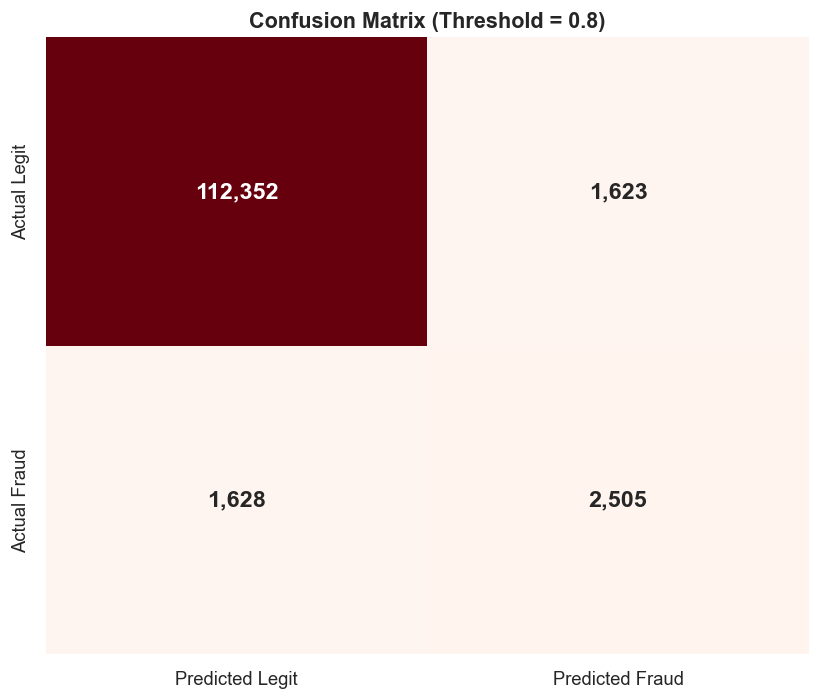


[SECTION 3] Confusion Matrix Breakdown
  True Negatives  (correctly identified legit) : 112,352
  False Positives (legit flagged as fraud)      : 1,623
  False Negatives (fraud missed)                : 1,628
  True Positives  (fraud correctly caught)       : 2,505


In [7]:
# ============================================================
# SECTION 3: CONFUSION MATRIX AT CHOSEN THRESHOLD Using optimal F1 threshold for business interpretation
# ============================================================

optimal_threshold = best_f1_row['threshold']
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Reds',
    xticklabels=['Predicted Legit', 'Predicted Fraud'],
    yticklabels=['Actual Legit', 'Actual Fraud'],
    cbar=False, annot_kws={'fontsize': 14, 'fontweight': 'bold'}
)
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eval_03_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f"\n[SECTION 3] Confusion Matrix Breakdown")
print(f"  True Negatives  (correctly identified legit) : {tn:,}")
print(f"  False Positives (legit flagged as fraud)      : {fp:,}")
print(f"  False Negatives (fraud missed)                : {fn:,}")
print(f"  True Positives  (fraud correctly caught)       : {tp:,}")

In [8]:
# ============================================================
# SECTION 4: FULL CLASSIFICATION REPORT
# ============================================================

print(f"\n[SECTION 4] Classification Report (Threshold = {optimal_threshold})")
print(classification_report(y_test, y_pred_optimal,target_names=['Legitimate', 'Fraud']))


[SECTION 4] Classification Report (Threshold = 0.8)
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99    113975
       Fraud       0.61      0.61      0.61      4133

    accuracy                           0.97    118108
   macro avg       0.80      0.80      0.80    118108
weighted avg       0.97      0.97      0.97    118108



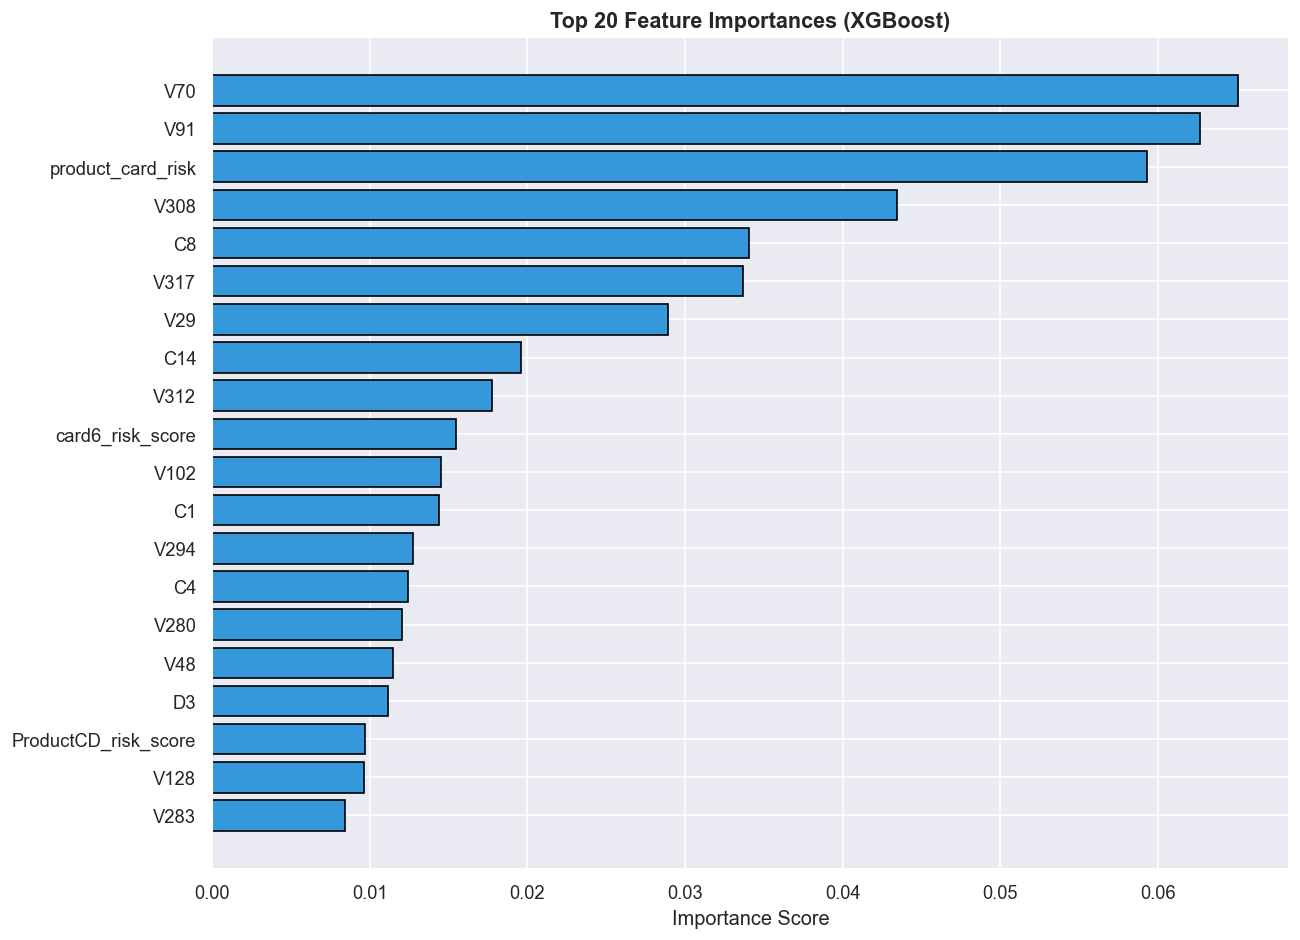


[SECTION 5] Top 10 Most Important Features
          feature  importance
              V70    0.065043
              V91    0.062687
product_card_risk    0.059273
             V308    0.043461
               C8    0.034062
             V317    0.033662
              V29    0.028907
              C14    0.019596
             V312    0.017728
 card6_risk_score    0.015467


In [10]:
# ============================================================
# SECTION 5: FEATURE IMPORTANCE (Built-in XGBoost)
# Business Question: What drives the model's decisions?
# Note: SHAP in Phase 7 will give deeper, per-prediction
#       explanations — this is the global view first
# ============================================================

importance = xgb_model.feature_importances_
feat_names = X_test.columns

importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importance
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(11, 8))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],color='#3498db', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eval_04_feature_importance.png', bbox_inches='tight')
plt.show()

print(f"\n[SECTION 5] Top 10 Most Important Features")
print(importance_df.head(10).to_string(index=False))

In [11]:
# ============================================================
# SECTION 6: SAVE EVALUATION ARTIFACTS
# ============================================================

threshold_df.to_csv('../reports/threshold_analysis.csv', index=False)
importance_df.to_csv('../reports/feature_importance.csv', index=False)

eval_summary = {
    'auc_roc': float(round(0.9399, 4)),
    'auc_pr': float(round(avg_precision, 4)),
    'optimal_threshold': float(optimal_threshold),
    'precision_at_optimal': float(best_f1_row['precision']),
    'recall_at_optimal': float(best_f1_row['recall']),
    'f1_at_optimal': float(best_f1_row['f1_score']),
    'true_positives': int(tp),
    'false_positives': int(fp),
    'false_negatives': int(fn),
    'true_negatives': int(tn)
}

import json
with open('../reports/eval_summary.json', 'w') as f:
    json.dump(eval_summary, f, indent=2)

print("========== PHASE 6 SUMMARY ==========")
print("AUC-ROC              : 0.9399")
print(f"AUC-PR               : {avg_precision:.4f}")
print(f"Optimal Threshold    : {optimal_threshold}")
print(f"Precision @ Optimal  : {best_f1_row['precision']}")
print(f"Recall @ Optimal     : {best_f1_row['recall']}")
print(f"F1 @ Optimal         : {best_f1_row['f1_score']}")
print("======================================")


========== PHASE 6 SUMMARY ==========
AUC-ROC              : 0.9399
AUC-PR               : 0.6350
Optimal Threshold    : 0.8
Precision @ Optimal  : 0.6068
Recall @ Optimal     : 0.6061
F1 @ Optimal         : 0.6065
